In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Jovuel/JovantriImmanuelGulo_2411532014_ML2526/refs/heads/main/Pekan2/Breast_cancer_data.csv')
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [3]:
print("Info Dataset:")
df.info()

print("Statistik deskriptif sebelum scaling:")
df.describe().round(2)

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB
Statistik deskriptif sebelum scaling:


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
count,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.63
std,3.52,4.30,24.30,351.91,0.01,0.48
min,6.98,9.71,43.79,143.50,0.05,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.00
50%,13.37,18.84,86.24,551.10,0.10,1.00
75%,15.78,21.80,104.10,782.70,0.11,1.00
max,28.11,39.28,188.50,2501.00,0.16,1.00


In [4]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print("Fitur yang akan di-scaling:")
print(X.columns.tolist())

Fitur yang akan di-scaling:
['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness']


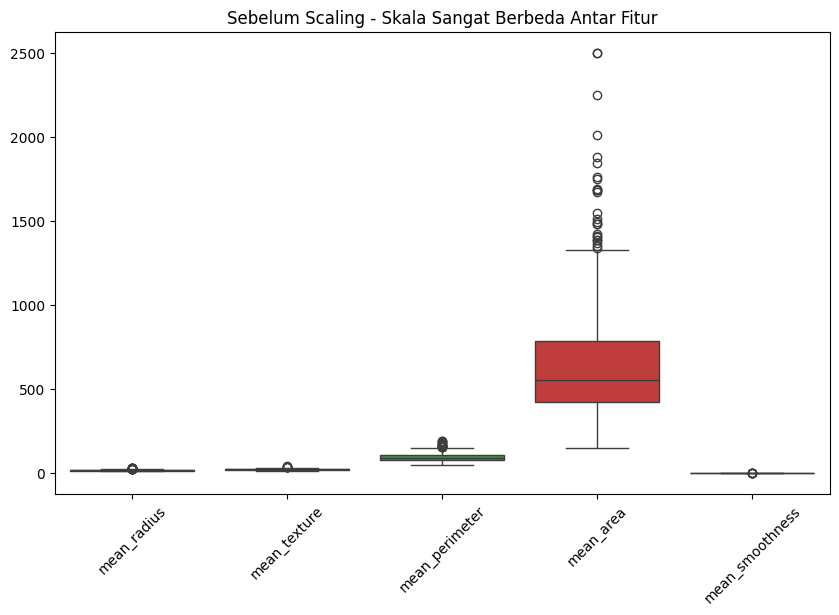

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(data=X)
plt.title("Sebelum Scaling - Skala Sangat Berbeda Antar Fitur")
plt.xticks(rotation=45)
plt.show()

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("5 baris pertama setelah scaling:")
X_scaled_df.head().round(3)

5 baris pertama setelah scaling:


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness
0,1.097,-2.073,1.270,0.984,1.568
1,1.830,-0.354,1.686,1.909,-0.827
2,1.580,0.456,1.567,1.559,0.942
3,-0.769,0.254,-0.593,-0.764,3.284
4,1.750,-1.152,1.777,1.826,0.280


In [7]:
print("Statistik SEBELUM scaling:")
print(X.describe().round(3))

print("\nStatistik SETELAH scaling:")
print(X_scaled_df.describe().round(3))

Statistik SEBELUM scaling:
       mean_radius  mean_texture  mean_perimeter  mean_area  mean_smoothness
count      569.000       569.000         569.000    569.000          569.000
mean        14.127        19.290          91.969    654.889            0.096
std          3.524         4.301          24.299    351.914            0.014
min          6.981         9.710          43.790    143.500            0.053
25%         11.700        16.170          75.170    420.300            0.086
50%         13.370        18.840          86.240    551.100            0.096
75%         15.780        21.800         104.100    782.700            0.105
max         28.110        39.280         188.500   2501.000            0.163

Statistik SETELAH scaling:
       mean_radius  mean_texture  mean_perimeter  mean_area  mean_smoothness
count      569.000       569.000         569.000    569.000          569.000
mean        -0.000         0.000          -0.000     -0.000           -0.000
std          1.001   

In [8]:
#Split Data
from sklearn.model_selection import train_test_split

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size =0.2, random_state=42, stratify=y
)

X_train, X_test, _, _ = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (455, 5)
Test size: (114, 5)


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_with_threshold(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Threshold = {threshold:.2f}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print(f"-"*40)
    
    return {'threshold' : threshold, 'acc' : acc, 'prec' : prec, 'rec' : rec, 'f1' : f1}    

In [11]:
from sklearn.linear_model import LogisticRegression

model_no_scale = LogisticRegression(max_iter=1000)
model_no_scale.fit(X_train, y_train)

proba_no_scale = model_no_scale.predict_proba(X_test)[:, 1]

print("Tanpa Scaling:")
results_no_scale = []
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    res = evaluate_with_threshold(y_test, proba_no_scale, th)
    results_no_scale.append(res)

Tanpa Scaling:
Threshold = 0.30
Accuracy : 0.9123
Precision : 0.9189
Recall : 0.9444
F1-score : 0.9315
Confusion Matrix:
 [[36  6]
 [ 4 68]]
----------------------------------------
Threshold = 0.40
Accuracy : 0.9123
Precision : 0.9306
Recall : 0.9306
F1-score : 0.9306
Confusion Matrix:
 [[37  5]
 [ 5 67]]
----------------------------------------
Threshold = 0.50
Accuracy : 0.9035
Precision : 0.9552
Recall : 0.8889
F1-score : 0.9209
Confusion Matrix:
 [[39  3]
 [ 8 64]]
----------------------------------------
Threshold = 0.60
Accuracy : 0.9035
Precision : 0.9552
Recall : 0.8889
F1-score : 0.9209
Confusion Matrix:
 [[39  3]
 [ 8 64]]
----------------------------------------
Threshold = 0.70
Accuracy : 0.8860
Precision : 0.9538
Recall : 0.8611
F1-score : 0.9051
Confusion Matrix:
 [[39  3]
 [10 62]]
----------------------------------------


In [12]:
model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_scaled, y_train)

proba_scaled = model_scaled.predict_proba(X_test_scaled)[:, 1]

print("Dengan Scaling:")
results_scaled = []
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    res = evaluate_with_threshold(y_test, proba_scaled, th)
    results_scaled.append(res)

Dengan Scaling:
Threshold = 0.30
Accuracy : 0.8947
Precision : 0.9286
Recall : 0.9028
F1-score : 0.9155
Confusion Matrix:
 [[37  5]
 [ 7 65]]
----------------------------------------
Threshold = 0.40
Accuracy : 0.8684
Precision : 0.9254
Recall : 0.8611
F1-score : 0.8921
Confusion Matrix:
 [[37  5]
 [10 62]]
----------------------------------------
Threshold = 0.50
Accuracy : 0.8596
Precision : 0.9375
Recall : 0.8333
F1-score : 0.8824
Confusion Matrix:
 [[38  4]
 [12 60]]
----------------------------------------
Threshold = 0.60
Accuracy : 0.8684
Precision : 0.9672
Recall : 0.8194
F1-score : 0.8872
Confusion Matrix:
 [[40  2]
 [13 59]]
----------------------------------------
Threshold = 0.70
Accuracy : 0.8421
Precision : 0.9655
Recall : 0.7778
F1-score : 0.8615
Confusion Matrix:
 [[40  2]
 [16 56]]
----------------------------------------


In [13]:
import pandas as pd

df_compare = pd.DataFrame({
    'Threshold': [r['threshold'] for r in results_no_scale],
    'Acc (No Scale)': [r['acc'] for r in results_no_scale],
    'F1 (No Scale)': [r['f1'] for r in results_no_scale],
    'Acc (Scaled)': [r['acc'] for r in results_scaled],
    'F1 (Scaled)': [r['f1'] for r in results_scaled],
})

print("Perbandingan Kinerja:")
print(df_compare.round(4))

# Kalau mau lihat yang mana lebih baik di threshold 0.5
print("\nPada threshold default 0.5:")
print(df_compare[df_compare['Threshold'] == 0.5])

Perbandingan Kinerja:
   Threshold  Acc (No Scale)  F1 (No Scale)  Acc (Scaled)  F1 (Scaled)
0        0.3          0.9123         0.9315        0.8947       0.9155
1        0.4          0.9123         0.9306        0.8684       0.8921
2        0.5          0.9035         0.9209        0.8596       0.8824
3        0.6          0.9035         0.9209        0.8684       0.8872
4        0.7          0.8860         0.9051        0.8421       0.8615

Pada threshold default 0.5:
   Threshold  Acc (No Scale)  F1 (No Scale)  Acc (Scaled)  F1 (Scaled)
2        0.5        0.903509       0.920863      0.859649     0.882353


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Hitung ROC curve dan AUC untuk No Scale
fpr_ns, tpr_ns, thresholds_ns = roc_curve(y_test, proba_no_scale)
roc_auc_ns = auc(fpr_ns, tpr_ns)

# Hitung ROC curve dan AUC untuk Scaled
fpr_s, tpr_s, thresholds_s = roc_curve(y_test, proba_scaled)
roc_auc_s = auc(fpr_s, tpr_s)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_ns, tpr_ns, color='blue', lw=2, label=f'No Scale (AUC = {roc_auc_ns:.4f})')
plt.plot(fpr_s, tpr_s, color='orange', lw=2, label=f'Scaled (AUC = {roc_auc_s:.4f})')

# Garis diagonal (random classifier)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.title('ROC Curve: Scaling vs Non-Scaling (Logistic Regression)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Print AUC saja kalau mau cepat lihat
print(f"AUC No Scale     : {roc_auc_ns:.4f}")
print(f"AUC Scaled       : {roc_auc_s:.4f}")